In [1]:
! pip install transformer_lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 129.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=27fe13b86a0db54c0b4d8343bafb7f018ed4493533d88b176542c907d4434320
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: beartype
    Found existing install

In [1]:
import os
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

# === Config ===
# RESULTS_DIR will be managed by the class

MODEL_NAMES = [
    # "gpt2-small",
    # "opt-125m",
    "meta-llama/Llama-3.2-1B-Instruct",
]

# Prompts (changeable)
prompt_real = "What is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "What is the freezing point of water on Planet Xylon, where gravity is twice that of Earth?"

# Device / dtype configuration (use half precision on GPU to save memory)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32
print(f"Runtime config -> device={DEVICE}, dtype={DTYPE}")

class LogitLensAnalysis:
    """Performs logit lens uncertainty analysis for a given model and prompts."""

    def __init__(self, model_name, prompt_real, prompt_fake, device, dtype, results_dir="./results_logit_lens"):
        self.model_name = model_name
        self.prompt_real = prompt_real
        self.prompt_fake = prompt_fake
        self.device = device
        self.dtype = dtype
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        self.model = None  # Model will be loaded during analysis

    def _get_uncertainty_tokens(self):
        """Build a list of token ids corresponding to uncertainty/refusal words."""
        words = [
            "unknown", "unsure", "don", "'t", "know", "can't", "unable", "impossible",
            "doesn't", "exist", "fictional", "imaginary", "no", "such", "thing",
            "hypothetical", "made", "up", "never", "happened"
        ]
        ids = []
        for w in words:
            try:
                toks = self.model.to_tokens(" " + w, prepend_bos=False)[0]
                ids += toks.tolist()
            except Exception:
                # Some tokenizers may not produce tokens for certain unicode or forms
                pass
        # Remove duplicates
        ids = sorted(list(set(ids)))
        return ids

    def _mass_by_layer(self, prompt, token_ids):
        """Compute uncertainty mass per layer using logit lens on the last position."""
        # Cache only resid_post to reduce memory
        print(f"entering _mass_by_layer for prompt: '{prompt[:50]}...' ")
        logits, cache = self.model.run_with_cache(
            prompt,
            names_filter=lambda n: ("hook_resid_post" in n),
        )
        print(f"exiting _mass_by_layer")
        masses = []
        for layer in range(self.model.cfg.n_layers):
            resid = cache[f"blocks.{layer}.hook_resid_post"][0, -1]  # [d_model]
            # Project through ln_final + unembed to get pseudo-logits
            try:
                pseudo_logits = self.model.unembed(self.model.ln_final(resid))  # [vocab]
            except Exception:
                # Fallback: some models may require different ordering; try unembed then ln_final
                pseudo_logits = self.model.ln_final(self.model.unembed(resid))
            probs = torch.softmax(pseudo_logits, dim=-1)
            masses.append(probs[token_ids].sum().item())
        return masses

    def _print_layerwise_table(self, layers, real_mass, fake_mass, out_txt=None):
      """Print (and optionally write) a descriptive table of layer-wise uncertainty masses."""
      delta = [f - r for f, r in zip(fake_mass, real_mass)]

      header = f"\nLayer-wise logit lens uncertainty mass ({self.model_name})\n"
      header += "Layer  |   Real Mass    |  Fake Mass    |   Delta\n"
      header += "------ | -------------- | ------------- | --------------"

      lines = [header]

      for l, r, f, d in zip(layers, real_mass, fake_mass, delta):
          lines.append(
              f"{l:>5}  | {r:>14.3e} | {f:>13.3e} | {d:>14.3e}"
          )

      table = "\n".join(lines)

      # Print to console
      print(table)

      # Optionally write to file
      if out_txt is not None:
          with open(out_txt, "w") as f:
              f.write(table + "\n")

    def _plot_logit_lens(self, layers, real_mass, fake_mass, out_path):
        plt.figure(figsize=(10, 6))
        plt.plot(layers, real_mass, label="Real prompt", marker="o", color="steelblue")
        plt.plot(layers, fake_mass, label="Fictional prompt", marker="o", color="coral")
        delta = [f - r for f, r in zip(fake_mass, real_mass)]
        plt.plot(layers, delta, label="Delta (fake - real)", linestyle="--", color="darkgreen")
        # Annotate max delta layer
        if len(delta) > 0:
            idx_max = max(range(len(delta)), key=lambda i: delta[i])
            plt.scatter([layers[idx_max]], [delta[idx_max]], color="darkgreen", zorder=3)
            plt.annotate(
                f"max Δ @ L{layers[idx_max]}\n{delta[idx_max]:.2e}",
                (layers[idx_max], delta[idx_max]),
                textcoords="offset points", xytext=(10, -10), ha="left",
                bbox=dict(boxstyle="round,pad=0.3", fc="#e8f5e9", ec="#2e7d32", alpha=0.8)
            )
        plt.xlabel("Layer")
        plt.ylabel("Uncertainty token mass (logit lens)")
        plt.title(
            f"Logit Lens Uncertainty vs Layer\n{self.model_name} — real vs fictional prompts",
        )
        plt.suptitle("Delta highlights where uncertainty begins to rise", fontsize=10, y=0.97)
        plt.grid(True, alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.show()
        plt.close()

    def run_analysis(self):
        """Executes the full logit lens analysis workflow for the initialized model."""
        print(f"\n{'='*60}")
        print(f"Processing model: {self.model_name}")
        print(f"{'='*60}")
        try:
            print(f"Loading {self.model_name}...")
            self.model = HookedTransformer.from_pretrained_no_processing(self.model_name, device=self.device, dtype=self.dtype)

            u_ids = self._get_uncertainty_tokens()
            print(f"Uncertainty token ids: {len(u_ids)} found")
            if not u_ids:
                print("Warning: No uncertainty tokens found; results may be uninformative.")

            print("Computing masses for real prompt...")
            real_mass = self._mass_by_layer(self.prompt_real, u_ids)

            print("Computing masses for fictional prompt...")
            fake_mass = self._mass_by_layer(self.prompt_fake, u_ids)

            layers = list(range(self.model.cfg.n_layers))
            model_dir = os.path.join(self.results_dir, self.model_name.replace("/", "_"))
            os.makedirs(model_dir, exist_ok=True)

            out_png = os.path.join(model_dir, "logit_lens_uncertainty_mass.png")

            print("Plotting and saving...")
            self._plot_logit_lens(layers, real_mass, fake_mass, out_png)
            self._print_layerwise_table(layers, real_mass, fake_mass, out_txt=os.path.join(model_dir, "logit_lens_uncertainty_mass.txt"))

            print(f"Saved plot: {out_png}")

        except Exception as e:
            print(f"Error processing {self.model_name}: {e}")
            import traceback
            traceback.print_exc()
        finally:
            # Free memory per model
            if self.model is not None:
                del self.model
                self.model = None # Clear reference
            torch.cuda.empty_cache() if torch.cuda.is_available() else None


Runtime config -> device=cuda, dtype=torch.float16


In [ ]:
!zip -r /content/results_logit_lens.zip /content/results_logit_lens/

updating: content/results_logit_lens/ (stored 0%)
updating: content/results_logit_lens/gpt2-small/ (stored 0%)
updating: content/results_logit_lens/gpt2-small/logit_lens_uncertainty_mass.txt (deflated 67%)
updating: content/results_logit_lens/gpt2-small/logit_lens_uncertainty_mass.png (deflated 13%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/ (stored 0%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/logit_lens_uncertainty_mass.txt (deflated 64%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B-Instruct/logit_lens_uncertainty_mass.png (deflated 11%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/ (stored 0%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/logit_lens_uncertainty_mass.txt (deflated 66%)
updating: content/results_logit_lens/meta-llama_Llama-3.2-1B/logit_lens_uncertainty_mass.png (deflated 10%)
  adding: content/results_logit_lens/qwen2.5-1.5b-instruct/ (stored 0%)
  adding: content/re

## testing on position independent sequence  
- llama-3.2-1b
- llama-3.2-1n-Instruct


### llama-3.2-1b


Processing model: meta-llama/Llama-3.2-1B
Loading meta-llama/Llama-3.2-1B...


Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water at standard at...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water on Planet Xylo...' 
exiting _mass_by_layer
Plotting and saving...


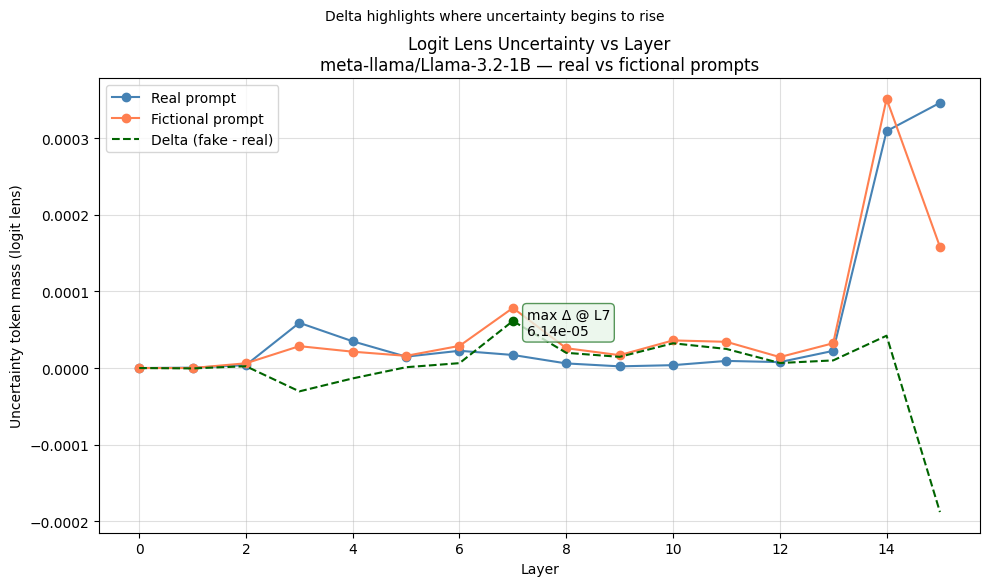


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      4.768e-07 |     0.000e+00 |     -4.768e-07
    2  |      3.874e-06 |     6.199e-06 |      2.325e-06
    3  |      5.901e-05 |     2.855e-05 |     -3.046e-05
    4  |      3.487e-05 |     2.134e-05 |     -1.353e-05
    5  |      1.484e-05 |     1.591e-05 |      1.073e-06
    6  |      2.253e-05 |     2.891e-05 |      6.378e-06
    7  |      1.705e-05 |     7.844e-05 |      6.139e-05
    8  |      6.020e-06 |     2.587e-05 |      1.985e-05
    9  |      2.205e-06 |     1.681e-05 |      1.460e-05
   10  |      3.755e-06 |     3.606e-05 |      3.231e-05
   11  |      9.298e-06 |     3.421e-05 |      2.491e-05
   12  |      7.749e-06 |     1.431e-05 |      6.557e-06
   13  |      2.241e-05 |     3.237e-05 |      9.954e-06
   14  |      3.092e-04 |    

In [ ]:
analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")


Processing model: meta-llama/Llama-3.2-1B
Loading meta-llama/Llama-3.2-1B...


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'On Earth, what is the freezing point of water at s...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'On Planet Xylon, what is the freezing point of wat...' 
exiting _mass_by_layer
Plotting and saving...


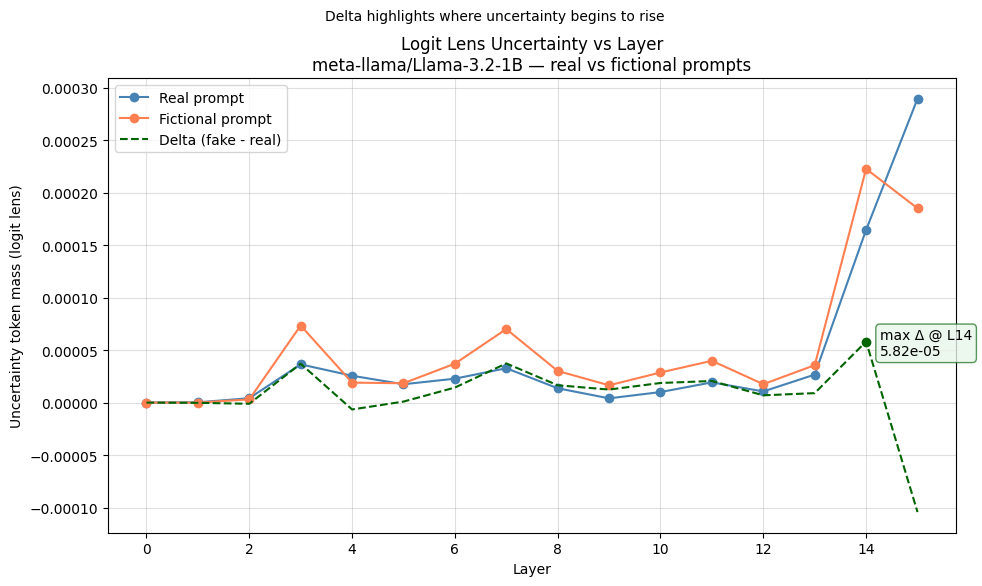


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      2.384e-07 |     0.000e+00 |     -2.384e-07
    2  |      4.172e-06 |     3.040e-06 |     -1.132e-06
    3  |      3.642e-05 |     7.343e-05 |      3.701e-05
    4  |      2.557e-05 |     1.901e-05 |     -6.557e-06
    5  |      1.746e-05 |     1.842e-05 |      9.537e-07
    6  |      2.277e-05 |     3.707e-05 |      1.431e-05
    7  |      3.272e-05 |     7.004e-05 |      3.731e-05
    8  |      1.365e-05 |     3.016e-05 |      1.651e-05
    9  |      4.053e-06 |     1.645e-05 |      1.240e-05
   10  |      1.001e-05 |     2.867e-05 |      1.866e-05
   11  |      1.925e-05 |     3.982e-05 |      2.056e-05
   12  |      1.061e-05 |     1.752e-05 |      6.914e-06
   13  |      2.664e-05 |     3.564e-05 |      9.000e-06
   14  |      1.645e-04 |    

In [2]:
prompt_real = "On Earth, what is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "On Planet Xylon, what is the freezing point of water at standard atmospheric pressure, where gravity is twice that of Earth?"

analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")

bw


Processing model: meta-llama/Llama-3.2-1B
Loading meta-llama/Llama-3.2-1B...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'Under normal Earth conditions, what is the freezin...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'On the fictional world Xylon, under otherwise simi...' 
exiting _mass_by_layer
Plotting and saving...


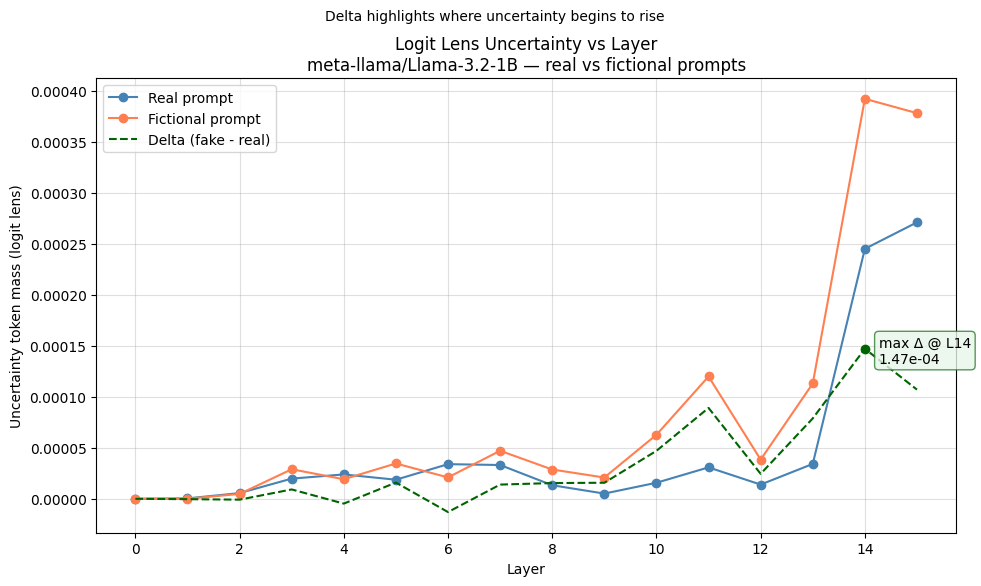


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      4.172e-07 |     5.960e-08 |     -3.576e-07
    2  |      5.603e-06 |     4.768e-06 |     -8.345e-07
    3  |      1.979e-05 |     2.897e-05 |      9.179e-06
    4  |      2.390e-05 |     1.919e-05 |     -4.709e-06
    5  |      1.872e-05 |     3.463e-05 |      1.591e-05
    6  |      3.397e-05 |     2.098e-05 |     -1.299e-05
    7  |      3.314e-05 |     4.709e-05 |      1.395e-05
    8  |      1.329e-05 |     2.873e-05 |      1.544e-05
    9  |      5.126e-06 |     2.086e-05 |      1.574e-05
   10  |      1.574e-05 |     6.276e-05 |      4.703e-05
   11  |      3.082e-05 |     1.199e-04 |      8.911e-05
   12  |      1.395e-05 |     3.844e-05 |      2.450e-05
   13  |      3.421e-05 |     1.131e-04 |      7.886e-05
   14  |      2.451e-04 |    

In [3]:
prompt_real = "Under normal Earth conditions, what is the freezing point of water?"
prompt_fake = "On the fictional world Xylon, under otherwise similar conditions, what is the freezing point of water?"

analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")

### llama3.2-1b-Instruct


Processing model: meta-llama/Llama-3.2-1B-Instruct
Loading meta-llama/Llama-3.2-1B-Instruct...


Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water at standard at...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'What is the freezing point of water on Planet Xylo...' 
exiting _mass_by_layer
Plotting and saving...


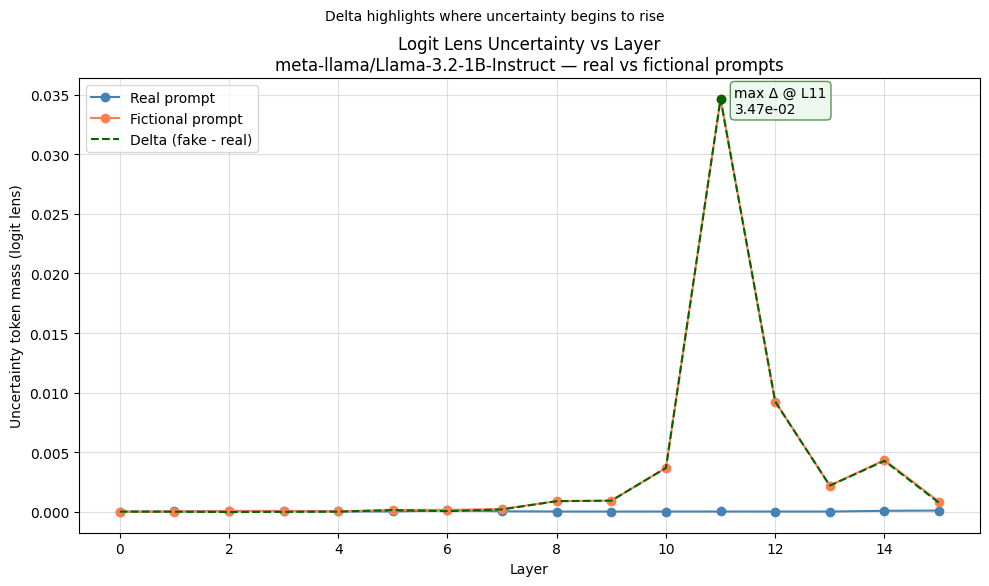


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B-Instruct)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      1.186e-05 |     4.828e-06 |     -7.033e-06
    2  |      6.020e-05 |     2.414e-05 |     -3.606e-05
    3  |      5.627e-05 |     3.558e-05 |     -2.068e-05
    4  |      2.056e-05 |     1.878e-05 |     -1.788e-06
    5  |      1.413e-05 |     1.423e-04 |      1.282e-04
    6  |      1.034e-04 |     1.454e-04 |      4.202e-05
    7  |      3.022e-05 |     2.162e-04 |      1.860e-04
    8  |      9.060e-06 |     8.864e-04 |      8.774e-04
    9  |      6.258e-06 |     9.241e-04 |      9.179e-04
   10  |      9.537e-06 |     3.677e-03 |      3.668e-03
   11  |      1.109e-05 |     3.467e-02 |      3.466e-02
   12  |      7.212e-06 |     9.247e-03 |      9.240e-03
   13  |      6.497e-06 |     2.190e-03 |      2.183e-03
   14  |      6.956e

In [ ]:
analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")


Processing model: meta-llama/Llama-3.2-1B-Instruct
Loading meta-llama/Llama-3.2-1B-Instruct...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'On Earth, what is the freezing point of water at s...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'On Planet Xylon, what is the freezing point of wat...' 
exiting _mass_by_layer
Plotting and saving...


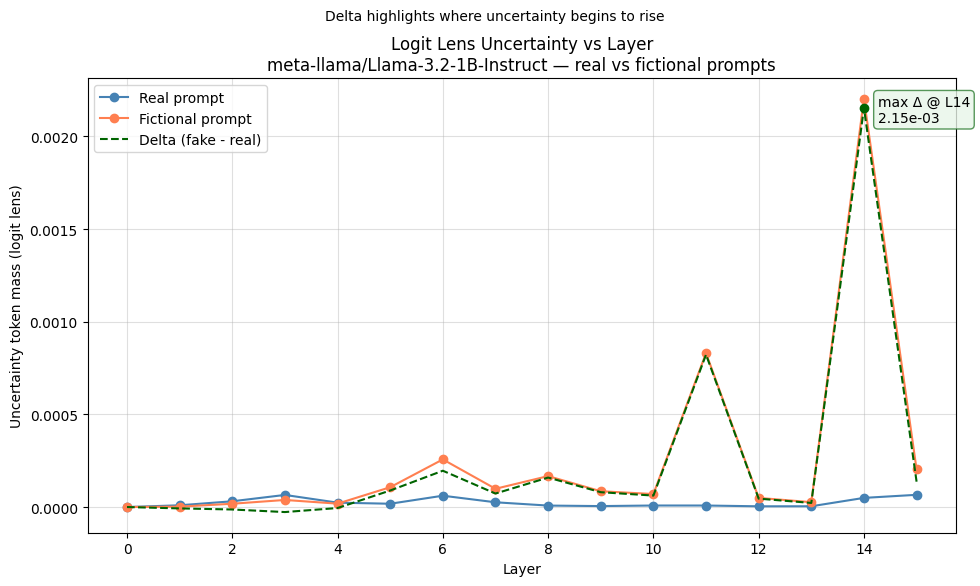


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B-Instruct)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      9.418e-06 |     2.027e-06 |     -7.391e-06
    2  |      3.105e-05 |     1.776e-05 |     -1.329e-05
    3  |      6.527e-05 |     3.815e-05 |     -2.712e-05
    4  |      2.366e-05 |     1.830e-05 |     -5.364e-06
    5  |      1.776e-05 |     1.069e-04 |      8.917e-05
    6  |      6.109e-05 |     2.570e-04 |      1.959e-04
    7  |      2.563e-05 |     9.847e-05 |      7.284e-05
    8  |      7.868e-06 |     1.669e-04 |      1.590e-04
    9  |      5.126e-06 |     8.523e-05 |      8.011e-05
   10  |      8.225e-06 |     7.004e-05 |      6.181e-05
   11  |      8.166e-06 |     8.307e-04 |      8.225e-04
   12  |      3.934e-06 |     4.929e-05 |      4.536e-05
   13  |      4.113e-06 |     2.617e-05 |      2.205e-05
   14  |      4.935e

In [2]:
prompt_real = "On Earth, what is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "On Planet Xylon, what is the freezing point of water at standard atmospheric pressure, where gravity is twice that of Earth?"

analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")


Processing model: meta-llama/Llama-3.2-1B-Instruct
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
Uncertainty token ids: 22 found
Computing masses for real prompt...
entering _mass_by_layer for prompt: 'Under normal Earth conditions, what is the freezin...' 
exiting _mass_by_layer
Computing masses for fictional prompt...
entering _mass_by_layer for prompt: 'On the fictional world Xylon, under otherwise simi...' 
exiting _mass_by_layer
Plotting and saving...


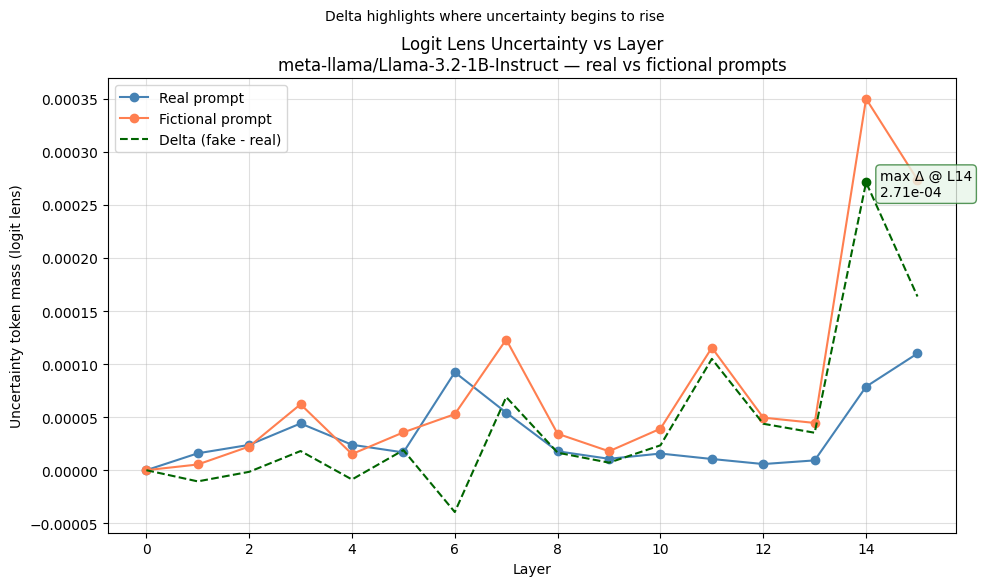


Layer-wise logit lens uncertainty mass (meta-llama/Llama-3.2-1B-Instruct)
Layer  |   Real Mass    |  Fake Mass    |   Delta
------ | -------------- | ------------- | --------------
    0  |      0.000e+00 |     0.000e+00 |      0.000e+00
    1  |      1.591e-05 |     5.364e-06 |     -1.055e-05
    2  |      2.384e-05 |     2.229e-05 |     -1.550e-06
    3  |      4.405e-05 |     6.211e-05 |      1.806e-05
    4  |      2.396e-05 |     1.520e-05 |     -8.762e-06
    5  |      1.675e-05 |     3.564e-05 |      1.889e-05
    6  |      9.227e-05 |     5.281e-05 |     -3.946e-05
    7  |      5.424e-05 |     1.231e-04 |      6.890e-05
    8  |      1.782e-05 |     3.433e-05 |      1.651e-05
    9  |      1.073e-05 |     1.782e-05 |      7.093e-06
   10  |      1.568e-05 |     3.910e-05 |      2.342e-05
   11  |      1.055e-05 |     1.155e-04 |      1.049e-04
   12  |      5.782e-06 |     4.953e-05 |      4.375e-05
   13  |      9.239e-06 |     4.452e-05 |      3.529e-05
   14  |      7.874e

In [3]:
prompt_real = "Under normal Earth conditions, what is the freezing point of water?"
prompt_fake = "On the fictional world Xylon, under otherwise similar conditions, what is the freezing point of water?"

analyzer = LogitLensAnalysis(
    model_name="meta-llama/Llama-3.2-1B-Instruct",
    prompt_real=prompt_real,
    prompt_fake=prompt_fake,
    device=DEVICE,
    dtype=DTYPE
)
analyzer.run_analysis()

print(f"\nAll results saved under {analyzer.results_dir}")

conclusion. they are position independt.  
uncertainity is in later layers